<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day07_practice2_MNIST_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 첫 CNN - 손글씨 숫자 인식 (교재 16장)
# MNIST 손글씨(0-9)를 분류

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("장치:", device)

EPOCHS = 5

장치: cpu


In [3]:
# [셀 1] MNIST 로드
def load_mnist(root="./data"):
  tf = transforms.ToTensor()  # 이미지를 PyTorch 텐서로 변환
  tr = datasets.MNIST(root=root, train=True, download=True, transform=tf) # 학습 6만장
  te = datasets.MNIST(root=root, train=False, download=True, transform=tf)
  return tr, te

train_data, test_data = load_mnist()
print(f"손글씨 학습 {len(train_data)}장 / 테스트 {len(test_data)}장")

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.14MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.70MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.84MB/s]

손글씨 학습 60000장 / 테스트 10000장


In [10]:
# [셀 2] CNN 설계 - shape 변화를 추적하며 읽기
class MnistCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.features = nn.Sequential( # 특징 추출부(무늬 감지)
        nn.Conv2d(1, 16, 3, padding=1), # (B,1,28,28) -> (B,16,28,28): 필터 16개, 패딩1로 크기유지
        nn.ReLU(),                      # 음수 제거 (비선형성)
        nn.MaxPool2d(2),                # ->(B,16,14,14): 2x2 풀링으로 절반 요약
        nn.Conv2d(16, 32, 3, padding=1), # ->(B,32,14,14): 필터 32개, 더 복잡한 무늬
        nn.ReLU(),
        nn.MaxPool2d(2),                 # ->(B, 32,7,7): 다시 절반
    )
    self.classifier = nn.Sequential( # 판단부(MLP)
        nn.Flatten(),                # ->(B, 32x7x7=1568): 3D 특징맵을 1D 벡터로 펼침
        nn.Linear(32 * 7 * 7, 128), # 1568 -> 128
        nn.ReLU(),
        nn.Dropout(0.3),            # 뉴런 30% 무작위 off -> 과적합 방지
        nn.Linear(128, 10),         # 128 -> 10 (숫자 0-9 로짓)
    )
  def forward(self, x):              # 순전파
    x = self.features(x)             # 특징 추출부 통과
    return self.classifier(x)        # 판단부 통과 -> 로짓 반환

model = MnistCNN().to(device)

# shape 추적 - 층마다 크기가 어떻게 변하는지 직접 찍어 확인 (디버깅 습관)
x = torch.randn(1, 1, 28, 28).to(device)
print("\n[shape 추적]:")
print("입력          :", tuple(x.shape))
for i, layer in enumerate(model.features):
      x = layer(x)
      if not isinstance(layer, nn.ReLU): # ReLU는 크기 안 바꾸므로 출력 생략
        print(f"{layer.__class__.__name__:12s}:", tuple(x.shape)) # 층 이름과 출력 shape

n_params = sum(p.numel() for p in model.parameters()) # 전체 학습 파라미터 개수 확인
print(f" 총 파라미터: {n_params:,}개")


[shape 추적]:
입력          : (1, 1, 28, 28)
Conv2d      : (1, 16, 28, 28)
MaxPool2d   : (1, 16, 14, 14)
Conv2d      : (1, 32, 14, 14)
MaxPool2d   : (1, 32, 7, 7)
 총 파라미터: 206,922개


In [16]:
# [셀 3] 학습
loss_fn = nn.CrossEntropyLoss() # 다중 분류 손실 (softmax+CE 내장, 로짓 입력)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        loss = loss_fn(model(images), labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    model.eval()
    correct = 0 # 맞은 개수

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).type(torch.float).sum().item() # 예측 == 정답 개수 누적

    acc = correct / len(test_data) # 정확도 = 맞은 수 / 전체

    print(f"epoch {epoch+1}/{EPOCHS} | loss {total_loss/len(train_loader):.4f} | 테스트 정확도 {acc:.4f}")

epoch 1/5 | loss 0.0710 | 테스트 정확도 0.9868
epoch 2/5 | loss 0.0537 | 테스트 정확도 0.9889
epoch 3/5 | loss 0.0465 | 테스트 정확도 0.9896
epoch 4/5 | loss 0.0384 | 테스트 정확도 0.9901
epoch 5/5 | loss 0.0350 | 테스트 정확도 0.9892


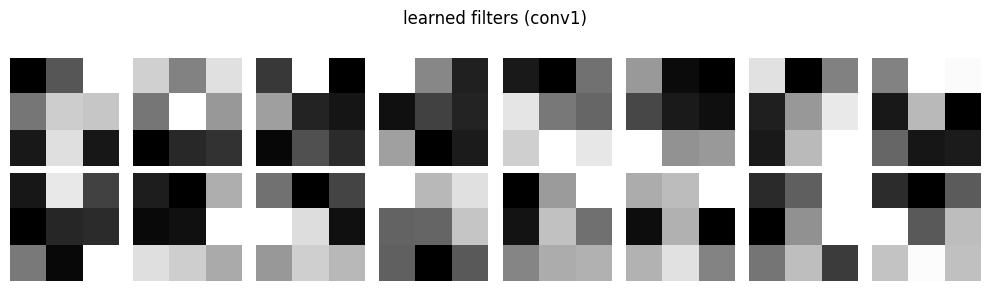

In [14]:
# [셀 4] 학습된 필터 구경(CNN이 스스로 만든 무늬 감지기) + 틀린 예측 살펴보기
# 첫 Conv 층이 학습한 무늬를 시각화
# 이 층이 학습을 통해 어떤 무늬(엣지, 곡선 등)를 감지하게 되었는지 담고 있다.
# nn.Conv2d(1, 16, 3, padding=1)

filters = model.features[0].weight.detach().cpu()
# (16, 1, 3, 3)
# .weight의 shape = (필터 개수, 입력 채널, 필터 크기 3x3)

fig, axes = plt.subplots(2, 8, figsize=(10, 3))

for i, ax in enumerate(axes.flat):
    ax.imshow(filters[i, 0], cmap="gray")
    ax.axis("off")

plt.suptitle("learned filters (conv1)")
plt.tight_layout()
plt.savefig("plot_filters.png")
plt.show()

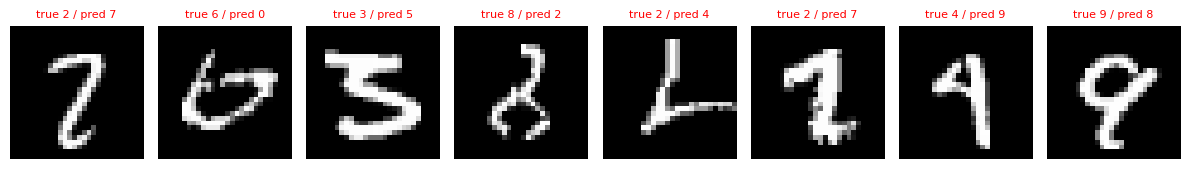

In [23]:
# [셀 5] 틀린 예측 살펴보기
model.eval()

wrongs = []

with torch.no_grad():

    for images, labels in test_loader:

        preds = model(images.to(device)).argmax(dim=1).cpu()

        for img, t, p in zip(images, labels, preds):

            if t != p: # 정답(t)과 예측(p)이 다르면
                wrongs.append((img, t.item(), p.item()))

        if len(wrongs) >= 8:break

fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for ax, (img, t, p) in zip(axes, wrongs[:8]):
    ax.imshow(img[0], cmap="gray")
    ax.set_title(f"true {t} / pred {p}", fontsize=8, color="red")
    ax.axis("off")

plt.tight_layout()
plt.savefig("plot2_wrong.png")
plt.show()